# 🏥 Face Skin Disease Classification — Industry-Grade Pipeline
### Multi-Model Transfer Learning | EfficientNetV2B0 · ResNet50 · DenseNet121 · MobileNetV3Large · ViT
---
> **Kaggle Notebook** | TensorFlow/Keras | 6-Class Skin Disease Classifier  
> Features: Focal Loss · Phase-wise Unfreezing · Ensemble · Full Metrics Suite

## 📦 Cell 1 — Install Dependencies

In [1]:
import subprocess, sys

def pip_install(package):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

pip_install('vit-keras')
pip_install('keras-tuner')
pip_install('scikit-learn')
pip_install('seaborn')
pip_install('imbalanced-learn')

print('✅ Dependencies installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 3.4 MB/s eta 0:00:00
✅ Dependencies installed.


## 🔧 Cell 2 — Imports

In [2]:
# ─── Standard Library ────────────────────────────────────────────────────────
import os, gc, json, warnings, random, math, shutil
from pathlib import Path
from collections import Counter
warnings.filterwarnings('ignore')

# ─── Numerical & Visualisation ───────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ─── Sklearn ─────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score,
    cohen_kappa_score, matthews_corrcoef, f1_score
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

# ─── TensorFlow / Keras ──────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, backend as K
from tensorflow.keras.applications import (
    EfficientNetV2B0,
    ResNet50,
    DenseNet121,
    MobileNetV3Large
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau,
    ModelCheckpoint, TensorBoard, CSVLogger
)
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.optimizers.schedules import CosineDecayRestarts
from tensorflow.keras.regularizers import l2

# ─── Seed Everything ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print(f'✅ TensorFlow {tf.__version__}')
print(f'✅ GPUs available: {tf.config.list_physical_devices("GPU")}')

2026-04-21 14:29:50.499019: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776781790.687781      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776781790.745666      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776781791.219820      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776781791.219854      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776781791.219857      22 computation_placer.cc:177] computation placer alr

✅ TensorFlow 2.19.0
✅ GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## ⚙️ Cell 3 — Global Configuration

In [3]:
# ─── Dataset Path ────────────────────────────────────────────────────────────
# Kaggle: update this path to match your dataset location
DATA_DIR = Path('/kaggle/input/datasets/shanmukhadattaboda/face-skin-disease-dataset-2-0/Face_Data')   # ← change if your dataset folder name differs

# ─── Training Hypers ─────────────────────────────────────────────────────────
IMG_SIZE             = 224
BATCH_SIZE           = 32
NUM_CLASSES          = 6
EPOCHS_PHASE1        = 15
EPOCHS_PHASE2        = 25
EPOCHS_PHASE3        = 30
BASE_LR              = 1e-3
FINETUNE_LR          = 1e-4
FULL_FT_LR           = 2e-5
DROPOUT_RATE         = 0.4
L2_REG               = 1e-4
MAX_IMAGES_PER_CLASS = 1500
TARGET_SIZE_BALANCE  = 1200
SAVE_DIR             = Path('/kaggle/working/saved_models')
SAVE_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR             = Path('/kaggle/working/plots')
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print('✅ Configuration set.')

✅ Configuration set.


## 🗂️ Cell 4 — Dataset Discovery & Validation

In [4]:
VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp'}

def discover_dataset(data_dir: Path):
    """Walk the directory tree, collect (path, label) pairs, report stats."""
    assert data_dir.exists(), f'❌ DATA_DIR not found: {data_dir}'
    classes = sorted([d.name for d in data_dir.iterdir() if d.is_dir()])
    assert len(classes) > 0, '❌ No sub-folders found in DATA_DIR.'

    records, bad_files = [], []
    for label_idx, cls in enumerate(classes):
        cls_dir = data_dir / cls
        for f in cls_dir.rglob('*'):
            if f.suffix.lower() in VALID_EXTS:
                records.append({'path': str(f), 'label': label_idx, 'class': cls})
            elif f.is_file():
                bad_files.append(str(f))

    df = pd.DataFrame(records)
    print(f'\n📊 Dataset Summary')
    print(f'  Total valid images : {len(df)}')
    print(f'  Non-image files    : {len(bad_files)}')
    print(f'  Classes ({len(classes)})        : {classes}\n')
    print(df.groupby('class')['path'].count().rename('count').to_string())
    return df, classes

df_full, CLASS_NAMES = discover_dataset(DATA_DIR)
print(f'\n✅ {len(CLASS_NAMES)} classes discovered.')


📊 Dataset Summary
  Total valid images : 9335
  Non-image files    : 1
  Classes (6)        : ['Acne', 'Eczema', 'Fungal', 'Normal', 'Skin_Cancer', 'pigmentation']

class
Acne            1592
Eczema          1545
Fungal          1512
Normal          1576
Skin_Cancer     1542
pigmentation    1568

✅ 6 classes discovered.


## 🧹 Cell 5 — Data Cleaning (Corrupt Image Removal)

In [5]:
from PIL import Image as PILImage

def is_valid_image(path: str, min_size: int = 32) -> bool:
    """Fully decode image with PIL to catch any corrupt or unreadable files."""
    try:
        with PILImage.open(path) as img:
            img.load()          # forces full decode — not just header check
            w, h = img.size
            if w < min_size or h < min_size:
                return False
            img.convert('RGB') # ensures it is RGB-convertible
        return True
    except Exception:
        return False

print('🔍 Scanning for corrupt / invalid images (may take ~2-3 min)...')
valid_mask = df_full['path'].apply(is_valid_image)
n_bad      = (~valid_mask).sum()
df_clean   = df_full[valid_mask].reset_index(drop=True)

print(f'  Removed corrupt/invalid images : {n_bad}')
print(f'  Clean dataset size             : {len(df_clean)}')
print('✅ Cleaning done.')

🔍 Scanning for corrupt / invalid images (may take ~2-3 min)...
  Removed corrupt/invalid images : 0
  Clean dataset size             : 9335
✅ Cleaning done.


## ⚖️ Cell 6 — Dataset Balancing


📊 Balanced class distribution:
class
Acne            1500
Eczema          1500
Fungal          1500
Normal          1500
Skin_Cancer     1500
pigmentation    1500


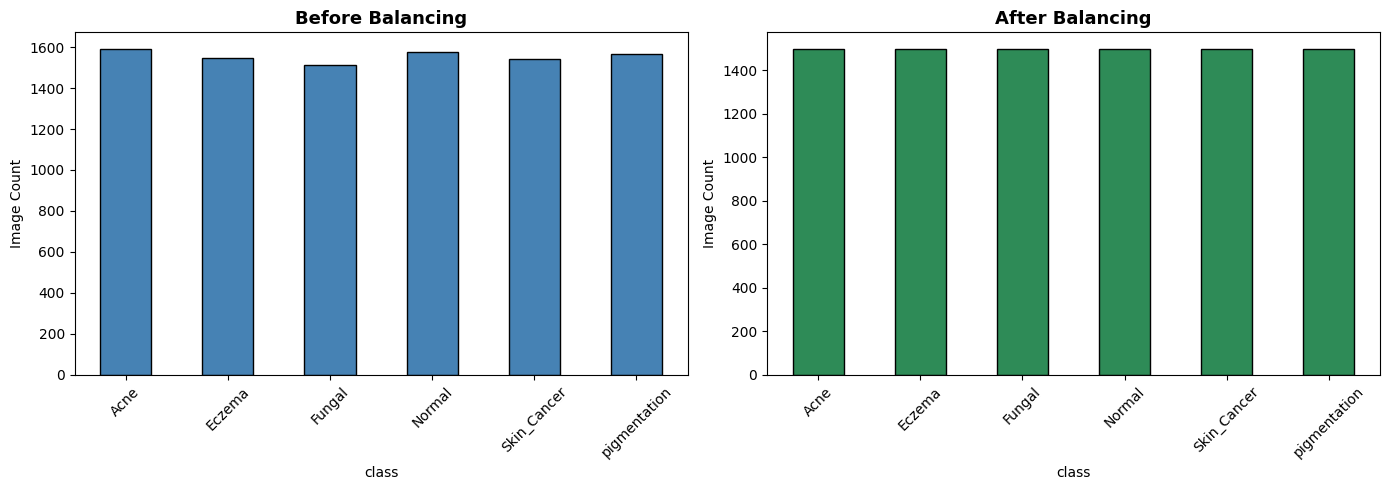

✅ Balancing done.


In [6]:
def balance_dataset(df: pd.DataFrame, target: int, max_cap: int, seed: int = 42):
    parts = []
    for cls_name, grp in df.groupby('class'):
        n = len(grp)
        if n < target:
            extra = grp.sample(target - n, replace=True, random_state=seed)
            parts.append(pd.concat([grp, extra]))
        elif n > max_cap:
            parts.append(grp.sample(max_cap, random_state=seed))
        else:
            parts.append(grp)
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)

df_balanced = balance_dataset(df_clean, TARGET_SIZE_BALANCE, MAX_IMAGES_PER_CLASS)
print('\n📊 Balanced class distribution:')
print(df_balanced.groupby('class')['path'].count().rename('count').to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_clean.groupby('class')['path'].count().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='k')
axes[0].set_title('Before Balancing', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Image Count'); axes[0].tick_params(axis='x', rotation=45)

df_balanced.groupby('class')['path'].count().plot(
    kind='bar', ax=axes[1], color='seagreen', edgecolor='k')
axes[1].set_title('After Balancing', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Image Count'); axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Balancing done.')

## ✂️ Cell 7 — Train / Validation / Test Split

In [7]:
paths  = df_balanced['path'].values
labels = df_balanced['label'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    paths, labels, test_size=0.30, stratify=labels, random_state=SEED)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

print(f'  Train : {len(X_train)} images')
print(f'  Valid : {len(X_val)}   images')
print(f'  Test  : {len(X_test)}  images')
print('✅ Split done.')

  Train : 6300 images
  Valid : 1350   images
  Test  : 1350  images
✅ Split done.


## 🔄 Cell 8 — tf.data Pipeline (Preprocessing + Augmentation)

**Fix applied:** Use `tf.io.decode_image` (universal decoder) + `image.set_shape([None, None, 3])`  
This handles JPEG, PNG, BMP, WebP, TIFF all in one call — no branching, no format errors.

I0000 00:00:1776781917.665797      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776781917.671668      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


✅ tf.data pipelines created.


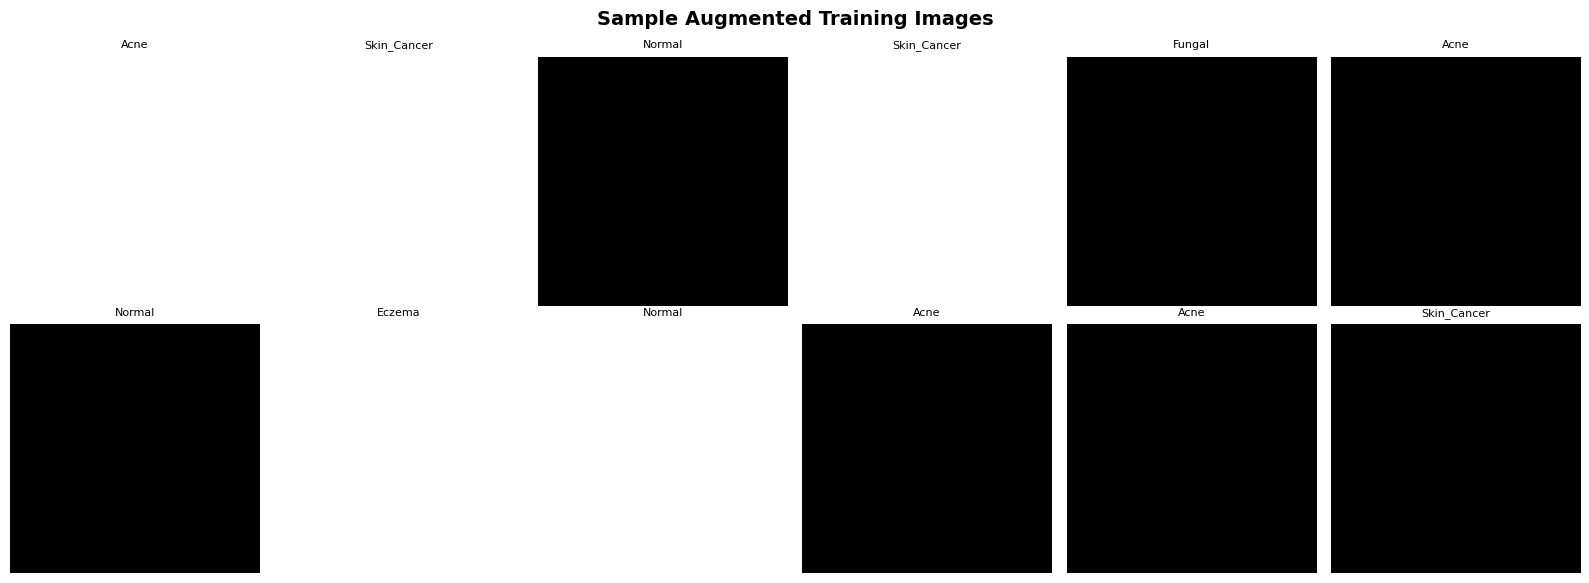

In [8]:
AUTOTUNE = tf.data.AUTOTUNE

# ─── Augmentation layer (mild — preserves medical texture) ───────────────────
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.08),
    layers.RandomContrast(0.10),
    layers.RandomBrightness(0.08),
    layers.RandomTranslation(0.05, 0.05),
], name='augmentation')

# ─── PIL-based decoder: handles JPEG/PNG/BMP/TIFF/WebP/any misnamed file ─────
from PIL import Image as PILImage
import io

def _pil_load(path_bytes):
    """Load any image format with PIL and return float32 RGB numpy array."""
    try:
        with PILImage.open(io.BytesIO(path_bytes)) as img:
            img = img.convert('RGB')
            img = img.resize((IMG_SIZE, IMG_SIZE), PILImage.BILINEAR)
            return np.array(img, dtype=np.float32) / 255.0
    except Exception:
        # Return black image on failure instead of crashing the pipeline
        return np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)

def preprocess_image(path, label, augment=False):
    # Read raw bytes from disk
    raw = tf.io.read_file(path)

    # tf.py_function bridges PIL into the TF graph — handles ALL formats including TIFF
    image = tf.py_function(
        func=lambda r: _pil_load(r.numpy()),
        inp=[raw],
        Tout=tf.float32
    )
    # REQUIRED: explicitly set shape so TF graph knows dimensions downstream
    image.set_shape([IMG_SIZE, IMG_SIZE, 3])

    if augment:
        image = data_augmentation(image, training=True)
    image = tf.clip_by_value(image, 0.0, 1.0)
    label = tf.cast(label, tf.int32)
    return image, label

def make_dataset(paths, labels, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (tf.constant(paths, dtype=tf.string),
         tf.constant(labels, dtype=tf.int32))
    )
    if shuffle:
        ds = ds.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=True)
    # num_parallel_calls=4 (not AUTOTUNE) — tf.py_function needs fixed thread count
    ds = ds.map(lambda p, l: preprocess_image(p, l, augment), num_parallel_calls=4)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train, augment=True,  shuffle=True)
val_ds   = make_dataset(X_val,   y_val,   augment=False, shuffle=False)
test_ds  = make_dataset(X_test,  y_test,  augment=False, shuffle=False)

print('✅ tf.data pipelines created.')

# ─── Sanity visual ────────────────────────────────────────────────────────────
sample_images, sample_labels = next(iter(train_ds))
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for i, ax in enumerate(axes.flat):
    img = sample_images[i].numpy()
    img = np.clip(img, 0.0, 1.0)
    ax.imshow(img)
    ax.set_title(CLASS_NAMES[sample_labels[i].numpy()], fontsize=8)
    ax.axis('off')
plt.suptitle('Sample Augmented Training Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## ⚖️ Cell 9 — Class Weights + Focal Loss

In [9]:
# ─── Class weights ────────────────────────────────────────────────────────────
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=y_train
)
CLASS_WEIGHT_DICT = {i: float(w) for i, w in enumerate(class_weights_array)}
print('Class weights:', {CLASS_NAMES[k]: round(v, 3) for k, v in CLASS_WEIGHT_DICT.items()})

# ─── Focal Loss ───────────────────────────────────────────────────────────────
class FocalLoss(keras.losses.Loss):
    """
    Multi-class Focal Loss.
    Reference: Lin et al. 2017 (https://arxiv.org/abs/1708.02002)
    """
    def __init__(self, gamma=2.0, alpha=0.25, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        y_true    = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred    = tf.cast(y_pred, tf.float32)
        y_pred    = tf.clip_by_value(tf.nn.softmax(y_pred, axis=-1), 1e-7, 1.0 - 1e-7)
        y_true_oh = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1], dtype=tf.float32)
        pt        = tf.reduce_sum(y_true_oh * y_pred, axis=-1)
        ce        = -tf.math.log(pt)
        focal     = self.alpha * tf.pow(1.0 - pt, self.gamma) * ce
        return tf.reduce_mean(focal)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'gamma': self.gamma, 'alpha': self.alpha})
        return cfg

print('✅ FocalLoss defined.')

Class weights: {'Acne': 1.0, 'Eczema': 1.0, 'Fungal': 1.0, 'Normal': 1.0, 'Skin_Cancer': 1.0, 'pigmentation': 1.0}
✅ FocalLoss defined.


## 🏗️ Cell 10 — Model Builder (Generic Head)

In [10]:
def build_classification_head(base_model, num_classes, dropout_rate, l2_reg, name='model'):
    """
    Attach classification head: GAP → BN → Dense(512) → Dropout → Dense(256) → Softmax
    """
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='input_image')
    x = base_model(inputs, training=False)

    if len(x.shape) == 4:
        x = layers.GlobalAveragePooling2D(name='gap')(x)
    elif len(x.shape) == 3:
        x = layers.Lambda(lambda t: t[:, 0, :], name='cls_token')(x)

    x = layers.BatchNormalization(name='bn_head')(x)
    x = layers.Dense(512, activation='relu',
                     kernel_regularizer=l2(l2_reg), name='dense_512')(x)
    x = layers.BatchNormalization(name='bn_512')(x)
    x = layers.Dropout(dropout_rate, name='drop_512')(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=l2(l2_reg), name='dense_256')(x)
    x = layers.BatchNormalization(name='bn_256')(x)
    x = layers.Dropout(dropout_rate * 0.5, name='drop_256')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    return Model(inputs, outputs, name=name)


def unfreeze_layers(base_model, n_layers: int):
    base_model.trainable = True
    for layer in base_model.layers[:-n_layers]:
        layer.trainable = False
    n_trainable = sum(1 for l in base_model.layers if l.trainable)
    print(f'  → {n_trainable}/{len(base_model.layers)} backbone layers trainable')


def freeze_all(base_model):
    base_model.trainable = False
    print('  → Backbone fully frozen')


print('✅ Model builder utilities ready.')

✅ Model builder utilities ready.


## 📊 Cell 11 — Callbacks & LR Schedule

In [11]:
def make_callbacks(model_name: str, monitor: str = 'val_accuracy', patience_es: int = 8):
    ckpt_path = str(SAVE_DIR / f'{model_name}_best.keras')
    callbacks = [
        ModelCheckpoint(
            filepath=ckpt_path,
            monitor=monitor, save_best_only=True,
            verbose=1, mode='max'
        ),
        EarlyStopping(
            monitor=monitor, patience=patience_es,
            restore_best_weights=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.4,
            patience=4, min_lr=1e-7, verbose=1
        ),
        CSVLogger(str(SAVE_DIR / f'{model_name}_training_log.csv'))
    ]
    return callbacks, ckpt_path


def cosine_lr_schedule(base_lr, epochs, warmup=3):
    def schedule(epoch):
        if epoch < warmup:
            return float(base_lr * (epoch + 1) / warmup)
        progress = (epoch - warmup) / max(1, epochs - warmup)
        return float(base_lr * 0.5 * (1 + math.cos(math.pi * progress)))
    return keras.callbacks.LearningRateScheduler(schedule, verbose=0)


print('✅ Callbacks ready.')

✅ Callbacks ready.


## 📈 Cell 12 — Evaluation & Plotting Utilities

In [12]:
def evaluate_model(model, test_ds, class_names, model_name):
    """Compute comprehensive evaluation metrics."""
    y_true, y_pred_prob = [], []
    for images, labels in test_ds:
        preds = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred_prob.extend(preds)

    y_true      = np.array(y_true)
    y_pred_prob = np.array(y_pred_prob)
    y_pred      = np.argmax(y_pred_prob, axis=1)

    acc    = (y_pred == y_true).mean()
    f1_mac = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    f1_wt  = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    kappa  = cohen_kappa_score(y_true, y_pred)
    mcc    = matthews_corrcoef(y_true, y_pred)
    report = classification_report(y_true, y_pred,
                                    target_names=class_names,
                                    zero_division=0, output_dict=True)

    y_bin = label_binarize(y_true, classes=np.arange(len(class_names)))
    try:
        auc_roc = roc_auc_score(y_bin, y_pred_prob, average='macro', multi_class='ovr')
    except Exception:
        auc_roc = float('nan')

    return {
        'model'      : model_name,
        'accuracy'   : round(float(acc), 4),
        'f1_macro'   : round(float(f1_mac), 4),
        'f1_weighted': round(float(f1_wt), 4),
        'kappa'      : round(float(kappa), 4),
        'mcc'        : round(float(mcc), 4),
        'auc_roc'    : round(float(auc_roc), 4),
        'report'     : report,
        'y_true'     : y_true,
        'y_pred'     : y_pred,
        'y_pred_prob': y_pred_prob,
    }


def plot_confusion_matrix(y_true, y_pred, class_names, model_name, save_dir):
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title(f'{model_name} — Confusion Matrix (Counts)', fontweight='bold')
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title(f'{model_name} — Confusion Matrix (Normalised)', fontweight='bold')
    axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

    plt.tight_layout()
    plt.savefig(save_dir / f'{model_name}_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_roc_curves(y_true, y_pred_prob, class_names, model_name, save_dir):
    n_classes = len(class_names)
    y_bin     = label_binarize(y_true, classes=np.arange(n_classes))

    fig, ax = plt.subplots(figsize=(10, 7))
    colors  = plt.cm.tab10(np.linspace(0, 1, n_classes))
    for i, (cls, col) in enumerate(zip(class_names, colors)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_pred_prob[:, i])
        roc_auc_val = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=col, lw=2, label=f'{cls} (AUC={roc_auc_val:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{model_name} — ROC Curves (One-vs-Rest)', fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_dir / f'{model_name}_roc_curves.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_training_history(history_dict, model_name, save_dir):
    merged = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}
    for h in history_dict:
        for k in merged:
            if k in h:
                merged[k].extend(h[k])

    epochs = range(1, len(merged['accuracy']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs, merged['accuracy'],     label='Train Acc', lw=2)
    axes[0].plot(epochs, merged['val_accuracy'], label='Val Acc',   lw=2, linestyle='--')
    axes[0].set_title(f'{model_name} — Accuracy', fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, merged['loss'],     label='Train Loss', lw=2)
    axes[1].plot(epochs, merged['val_loss'], label='Val Loss',   lw=2, linestyle='--')
    axes[1].set_title(f'{model_name} — Loss', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.suptitle(f'{model_name} Training Curves', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(save_dir / f'{model_name}_training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_per_class_metrics(report_dict, class_names, model_name, save_dir):
    metrics_list = ['precision', 'recall', 'f1-score']
    data = {m: [report_dict[c][m] for c in class_names] for m in metrics_list}
    df_m = pd.DataFrame(data, index=class_names)

    ax = df_m.plot(kind='bar', figsize=(12, 5), width=0.7, edgecolor='k',
                   color=['#4C72B0', '#55A868', '#C44E52'])
    ax.set_title(f'{model_name} — Per-Class Metrics', fontsize=13, fontweight='bold')
    ax.set_ylabel('Score'); ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(loc='lower right')
    ax.grid(axis='y', alpha=0.3)
    for bar in ax.patches:
        ax.annotate(f'{bar.get_height():.2f}',
                    (bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01),
                    ha='center', va='bottom', fontsize=7)
    plt.tight_layout()
    plt.savefig(save_dir / f'{model_name}_per_class_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()


print('✅ Evaluation utilities ready.')

✅ Evaluation utilities ready.


## 🚀 Cell 13 — Phase-Wise Training Function

**Fix applied:** `SparseTopKCategoricalAccuracy` instead of `TopKCategoricalAccuracy`  
Reason: our pipeline yields integer labels, not one-hot — Sparse version handles this correctly.

In [13]:
ALL_METRICS   = []
ALL_HISTORIES = {}


def train_model_phased(
    model_name: str,
    base_model,
    unfreeze_phase2: int,
    unfreeze_phase3: int,
):
    """
    Three-phase training:
      Phase 1 – Head only  (backbone frozen)
      Phase 2 – Partial unfreeze (last N layers)
      Phase 3 – Full backbone fine-tune
    """
    print(f'\n{"+"*70}')
    print(f'  🔵 Training: {model_name}')
    print(f'{"+"*70}')

    model     = build_classification_head(
        base_model, NUM_CLASSES, DROPOUT_RATE, L2_REG, name=model_name)
    histories = []

    # ── PHASE 1 — Frozen backbone ────────────────────────────────────────────
    print('\n📌 Phase 1 — Frozen backbone, warm up head')
    freeze_all(base_model)
    model.compile(
        optimizer=Adam(BASE_LR),
        loss=FocalLoss(gamma=2.0, alpha=0.25),
        metrics=[
            'accuracy',
            keras.metrics.SparseTopKCategoricalAccuracy(k=2, name='top2_accuracy')
        ]
    )
    cbs1, _ = make_callbacks(f'{model_name}_p1', patience_es=6)
    cbs1.append(cosine_lr_schedule(BASE_LR, EPOCHS_PHASE1))
    h1 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_PHASE1,
                   callbacks=cbs1, class_weight=CLASS_WEIGHT_DICT, verbose=1)
    histories.append(h1.history)

    # ── PHASE 2 — Partial unfreeze ───────────────────────────────────────────
    print(f'\n📌 Phase 2 — Partial unfreeze (last {unfreeze_phase2} layers)')
    unfreeze_layers(base_model, unfreeze_phase2)
    model.compile(
        optimizer=Adam(FINETUNE_LR),
        loss=FocalLoss(gamma=2.0, alpha=0.25),
        metrics=[
            'accuracy',
            keras.metrics.SparseTopKCategoricalAccuracy(k=2, name='top2_accuracy')
        ]
    )
    cbs2, _ = make_callbacks(f'{model_name}_p2', patience_es=7)
    cbs2.append(cosine_lr_schedule(FINETUNE_LR, EPOCHS_PHASE2))
    h2 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_PHASE2,
                   callbacks=cbs2, class_weight=CLASS_WEIGHT_DICT, verbose=1)
    histories.append(h2.history)

    # ── PHASE 3 — Full fine-tune ─────────────────────────────────────────────
    print(f'\n📌 Phase 3 — Full fine-tune (last {unfreeze_phase3} layers)')
    unfreeze_layers(base_model, unfreeze_phase3)
    model.compile(
        optimizer=AdamW(learning_rate=FULL_FT_LR, weight_decay=1e-5),
        loss=FocalLoss(gamma=2.0, alpha=0.25),
        metrics=[
            'accuracy',
            keras.metrics.SparseTopKCategoricalAccuracy(k=2, name='top2_accuracy')
        ]
    )
    cbs3, _ = make_callbacks(f'{model_name}_p3', patience_es=8)
    cbs3.append(cosine_lr_schedule(FULL_FT_LR, EPOCHS_PHASE3))
    h3 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_PHASE3,
                   callbacks=cbs3, class_weight=CLASS_WEIGHT_DICT, verbose=1)
    histories.append(h3.history)

    # ── Save ─────────────────────────────────────────────────────────────────
    final_path = str(SAVE_DIR / f'{model_name}_final.keras')
    model.save(final_path)
    print(f'\n💾 Model saved → {final_path}')

    # ── Evaluate ─────────────────────────────────────────────────────────────
    metrics = evaluate_model(model, test_ds, CLASS_NAMES, model_name)
    print(f'\n📊 {model_name} Test Results:')
    print(f'  Accuracy   : {metrics["accuracy"]:.4f}')
    print(f'  F1 (macro) : {metrics["f1_macro"]:.4f}')
    print(f'  AUC-ROC    : {metrics["auc_roc"]:.4f}')
    print(f'  Cohen κ    : {metrics["kappa"]:.4f}')
    print(f'  MCC        : {metrics["mcc"]:.4f}')
    print('\n' + classification_report(
        metrics['y_true'], metrics['y_pred'],
        target_names=CLASS_NAMES, zero_division=0))

    # ── Plots ────────────────────────────────────────────────────────────────
    plot_training_history(histories, model_name, PLOT_DIR)
    plot_confusion_matrix(metrics['y_true'], metrics['y_pred'],
                          CLASS_NAMES, model_name, PLOT_DIR)
    plot_roc_curves(metrics['y_true'], metrics['y_pred_prob'],
                    CLASS_NAMES, model_name, PLOT_DIR)
    plot_per_class_metrics(metrics['report'], CLASS_NAMES, model_name, PLOT_DIR)

    ALL_METRICS.append(metrics)
    ALL_HISTORIES[model_name] = histories

    # ── Cleanup ──────────────────────────────────────────────────────────────
    del model
    gc.collect()
    K.clear_session()

    return metrics


print('✅ Training function ready.')

✅ Training function ready.


## 🤖 Cell 14 — Train Model 1: EfficientNetV2B0

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
  🔵 Training: EfficientNetV2B0
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

📌 Phase 1 — Frozen backbone, warm up head
  → Backbone fully frozen
Epoch 1/15


I0000 00:00:1776781936.220256      90 service.cc:152] XLA service 0x7a31a00132f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776781936.220300      90 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776781936.220304      90 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776781939.954530      90 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-21 14:32:26.962067: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-21 14:32:27.101238: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-21 14:32:28.471207: E external/local_xl

  3/197 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.1753 - loss: 0.4230 - top2_accuracy: 0.3507

I0000 00:00:1776781956.814639      90 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


196/197 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.1628 - loss: 0.4269 - top2_accuracy: 0.3320

2026-04-21 14:33:43.468722: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-21 14:33:43.605736: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-21 14:33:45.024192: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-21 14:33:45.165656: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.1628 - loss: 0.4269 - top2_accuracy: 0.3319

2026-04-21 14:34:09.356747: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-21 14:34:09.490443: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-21 14:34:10.861828: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-21 14:34:11.003037: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_accuracy improved from -inf to 0.16667, saving model to /kaggle/working/saved_models/EfficientNetV2B0_p1_best.keras
197/197 ━━━━━━━━━━━━━━━━━━━━ 130s 498ms/step - accuracy: 0.1628 - loss: 0.4269 - top2_accuracy: 0.3319 - val_accuracy: 0.1667 - val_loss: 0.4133 - val_top2_accuracy: 0.3333 - learning_rate: 3.3333e-04
Epoch 2/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.1584 - loss: 0.4199 - top2_accuracy: 0.3191
Epoch 2: val_accuracy did not improve from 0.16667
197/197 ━━━━━━━━━━━━━━━━━━━━ 68s 346ms/step - accuracy: 0.1585 - loss: 0.4199 - top2_accuracy: 0.3191 - val_accuracy: 0.1659 - val_loss: 0.3994 - val_top2_accuracy: 0.3333 - learning_rate: 6.6667e-04
Epoch 3/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - accuracy: 0.1712 - loss: 0.4011 - top2_accuracy: 0.3455
Epoch 3: val_accuracy did not improve from 0.16667
197/197 ━━━━━━━━━━━━━━━━━━━━ 70s 357ms/step - accuracy: 0.1712 - loss: 0.4011 - top2_accuracy: 0.3454 - val_accuracy: 0.1667 - val_loss: 0.3805

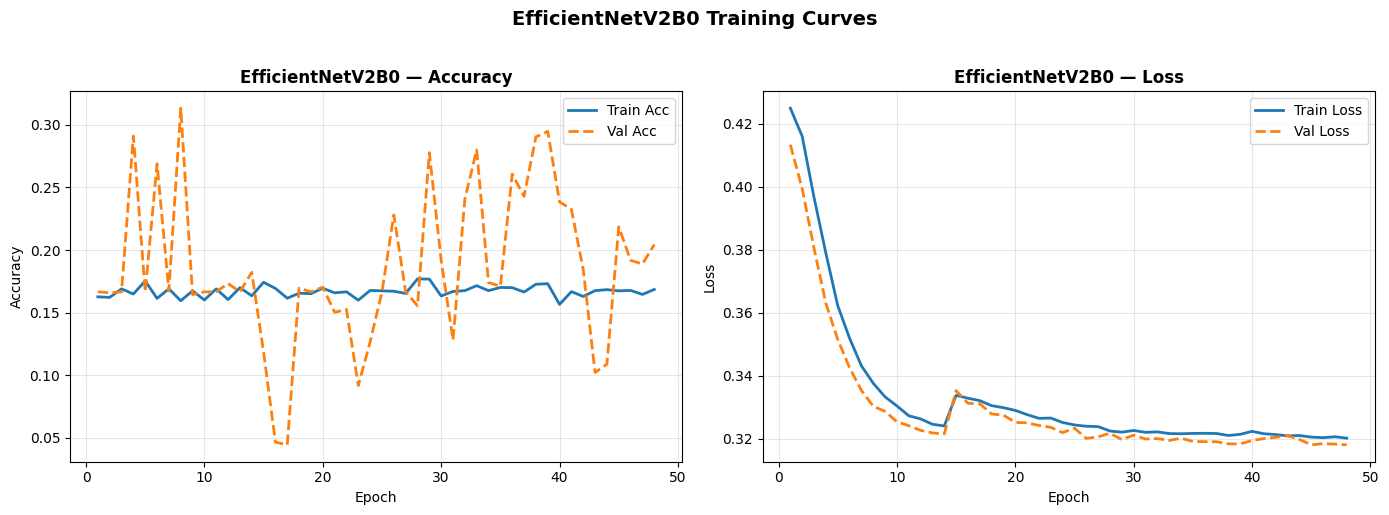

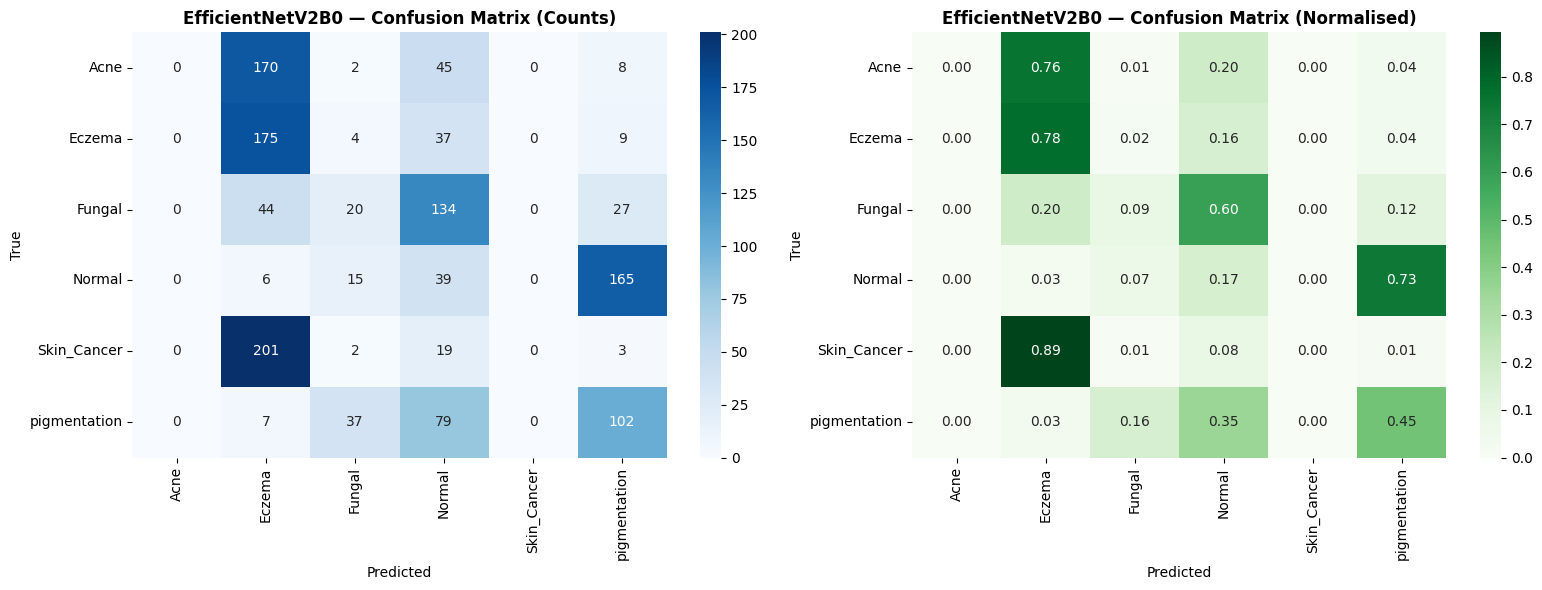

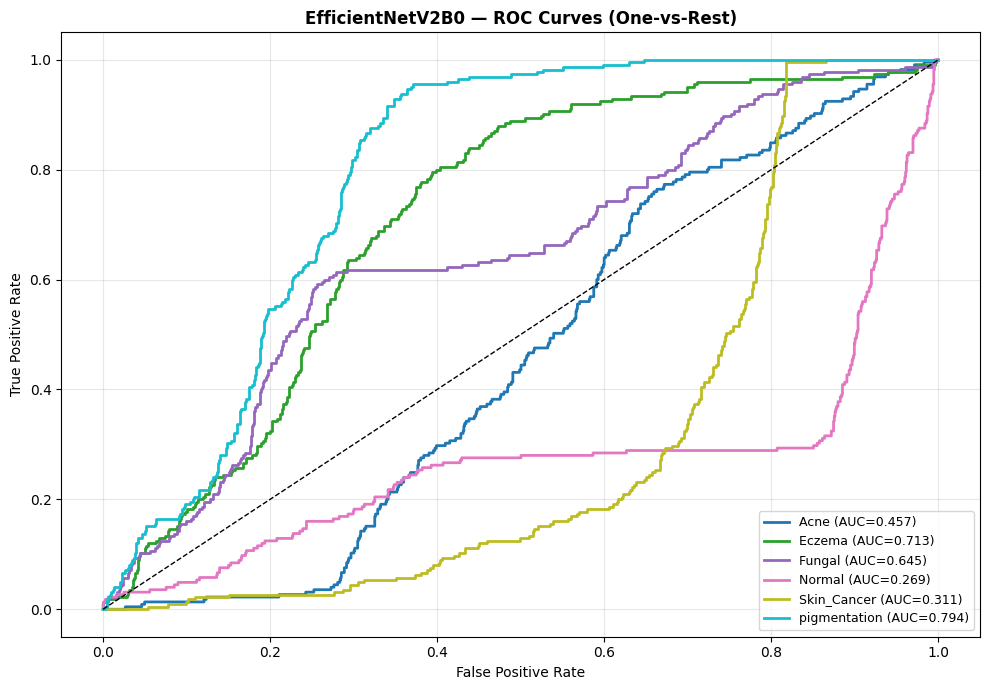

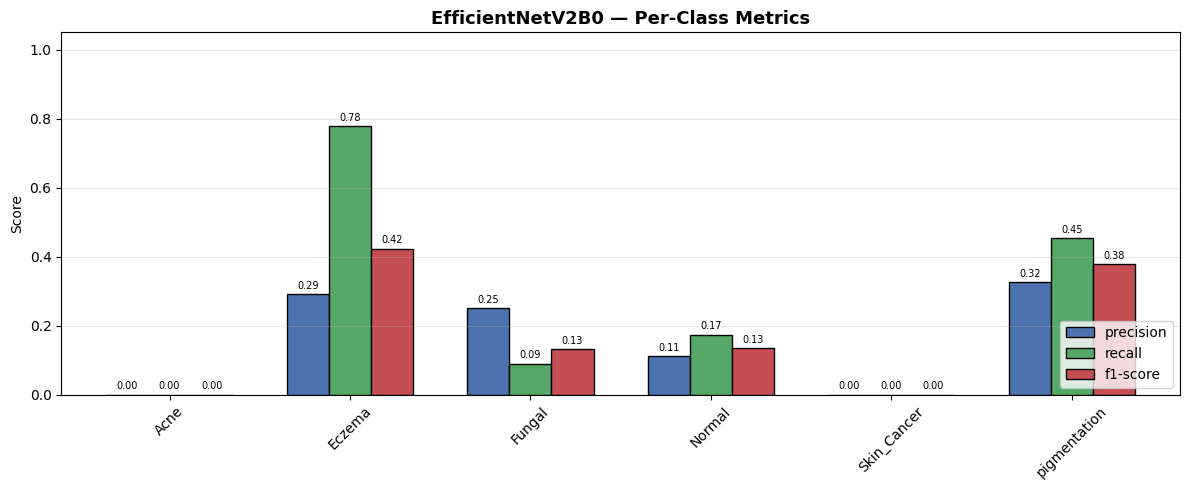

49247

In [14]:
efficientnet_base = EfficientNetV2B0(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_preprocessing=True
)
metrics_eff = train_model_phased(
    model_name='EfficientNetV2B0',
    base_model=efficientnet_base,
    unfreeze_phase2=100,
    unfreeze_phase3=200,
)
del efficientnet_base; gc.collect()

## 🤖 Cell 15 — Train Model 2: ResNet50

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
  🔵 Training: ResNet50
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

📌 Phase 1 — Frozen backbone, warm up head
  → Backbone fully frozen
Epoch 1/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.1774 - loss: 0.4035 - top2_accuracy: 0.3506
Epoch 1: val_accuracy improved from -inf to 0.18667, saving model to /kaggle/working/saved_models/ResNet50_p1_best.keras
197/197 ━━━━━━━━━━━━━━━━━━━━ 110s 471ms/step - accuracy: 0.1774 - loss: 0.4034 - top2_accuracy: 0.3506 - val_accuracy: 0.1867 - val_loss: 0.3585 - val_top2_accuracy: 0.3319 - learning_rate: 3.3333e-04
Epoch 2/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.1637 - loss: 0.3684 - top2_accuracy: 0.3280
Epoch 2: val_accuracy improved from 0.18667 to 0.19407, saving model to /kaggle/working/saved_models/ResNet50_p1_best.keras
197/197 ━━━━━━━━━━━━━━━━━━━━ 81s 409ms/step 

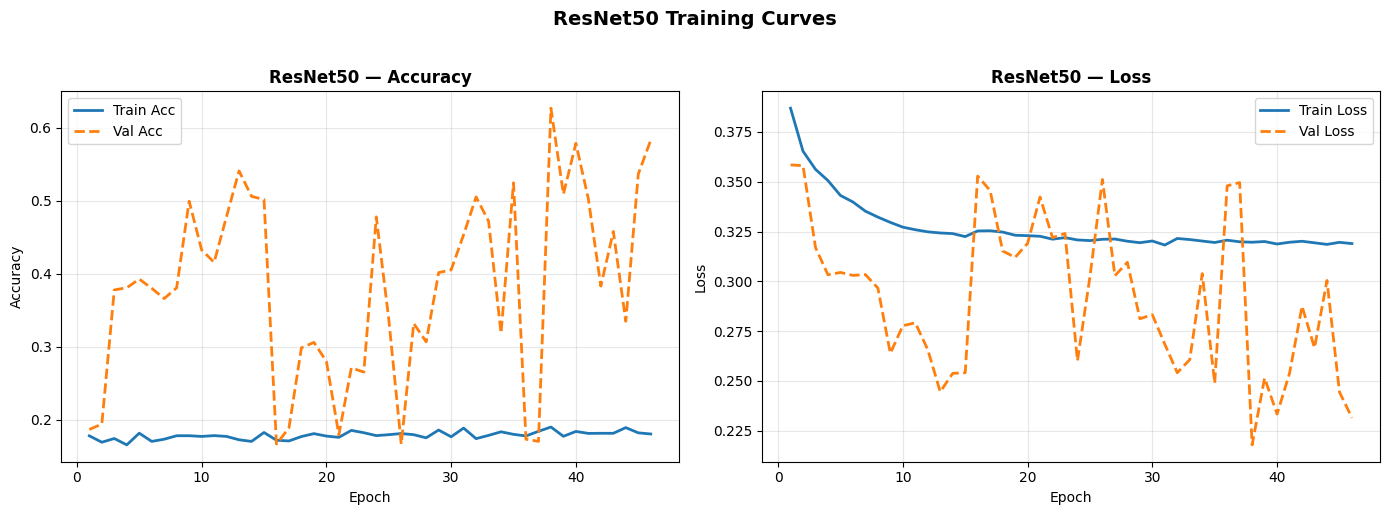

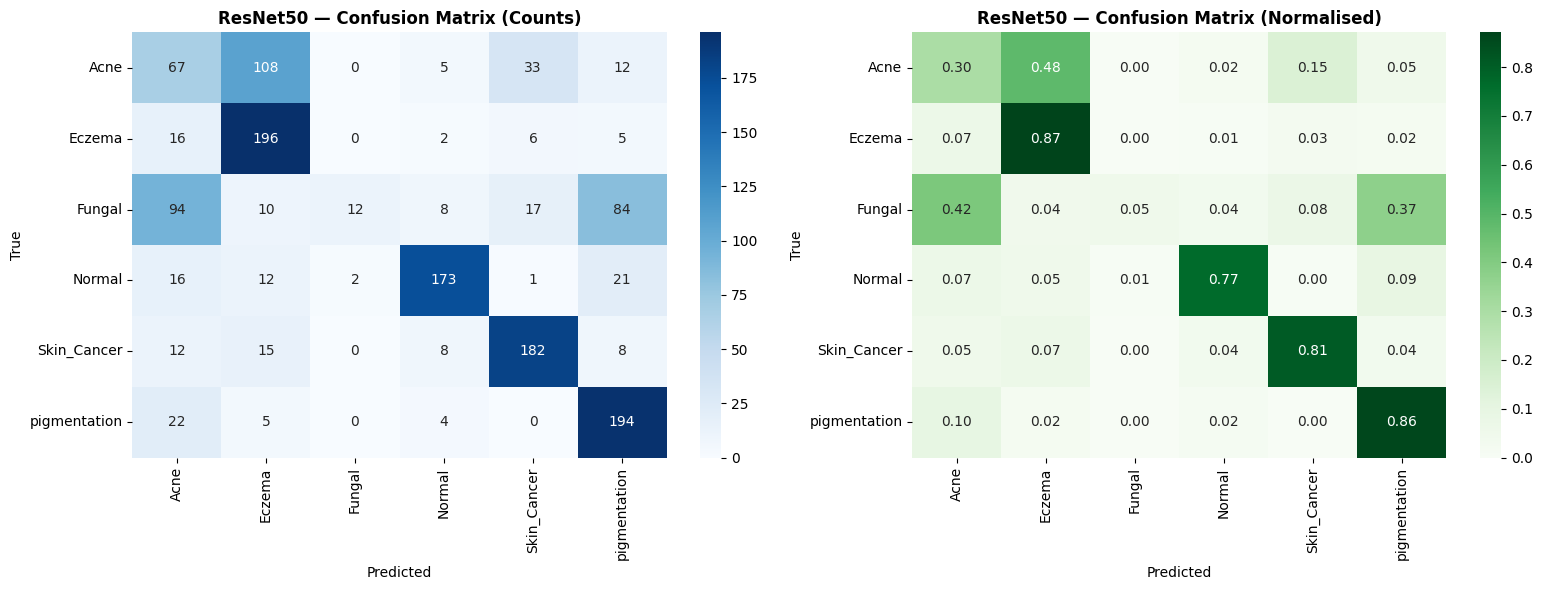

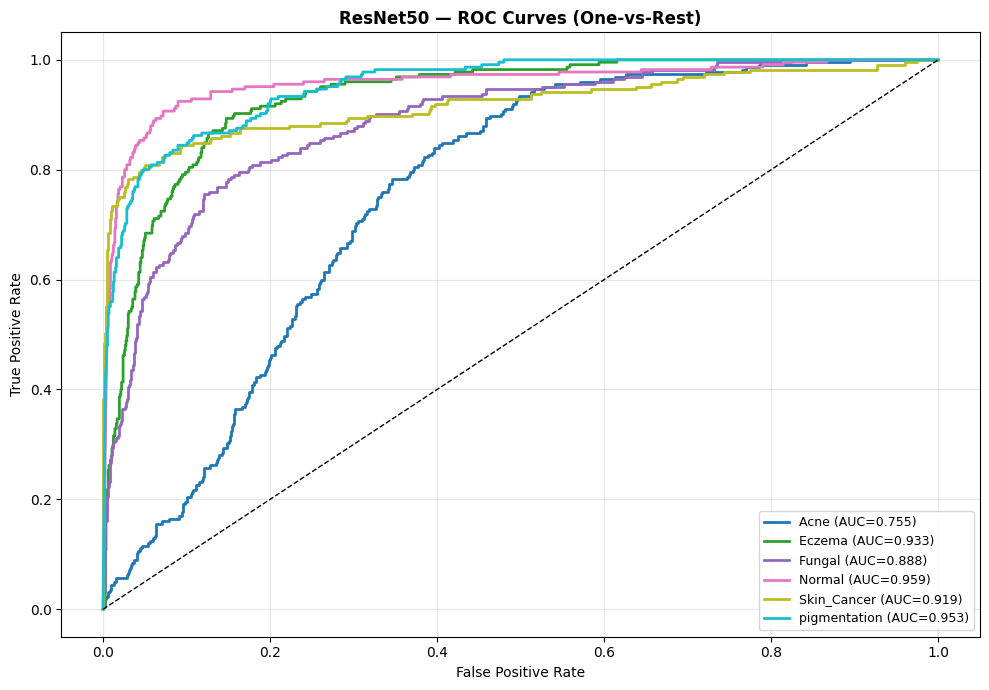

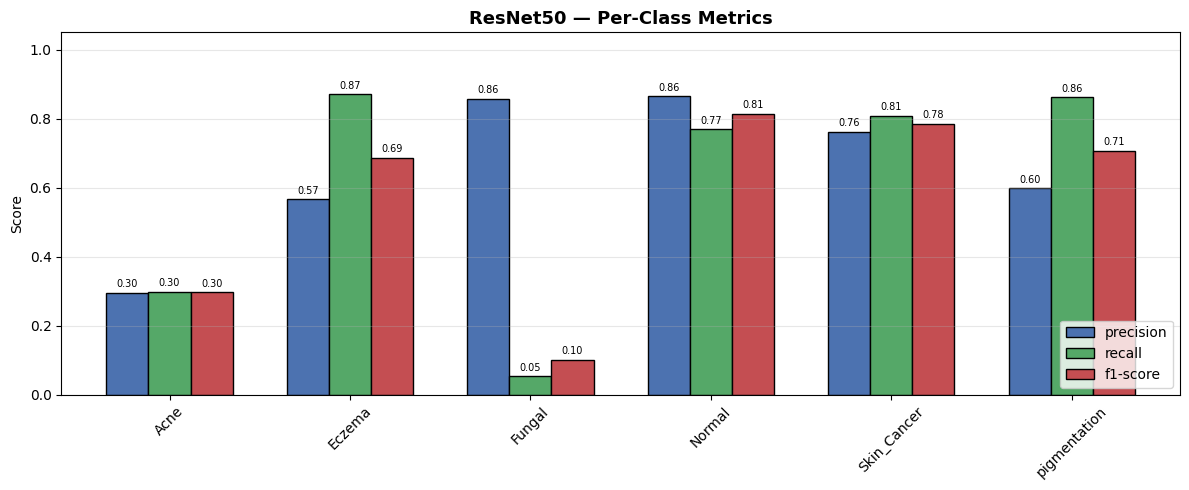

78591

In [15]:
resnet_base = ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
metrics_res = train_model_phased(
    model_name='ResNet50',
    base_model=resnet_base,
    unfreeze_phase2=50,
    unfreeze_phase3=100,
)
del resnet_base; gc.collect()

## 🤖 Cell 16 — Train Model 3: DenseNet121

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
  🔵 Training: DenseNet121
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

📌 Phase 1 — Frozen backbone, warm up head
  → Backbone fully frozen
Epoch 1/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.1690 - loss: 0.4088 - top2_accuracy: 0.3378
Epoch 1: val_accuracy improved from -inf to 0.43926, saving model to /kaggle/working/saved_models/DenseNet121_p1_best.keras
197/197 ━━━━━━━━━━━━━━━━━━━━ 147s 588ms/step - accuracy: 0.1690 - loss: 0.4087 - top2_accuracy: 0.3378 - val_accuracy: 0.4393 - val_loss: 0.3345 - val_top2_accuracy: 0.6333 - learning_rate: 3.3333e-04
Epoch 2/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.1720 - loss: 0.3847 - top2_accuracy: 0.3407
Epoch 2: val_accuracy did not improve from 0.43926
197/197 ━━━━━━━━━━━━━━━━━━━━ 80s 403ms/step - accuracy: 0.1721 - loss: 0.3847 - top2_accuracy: 0.3407 - val_acc

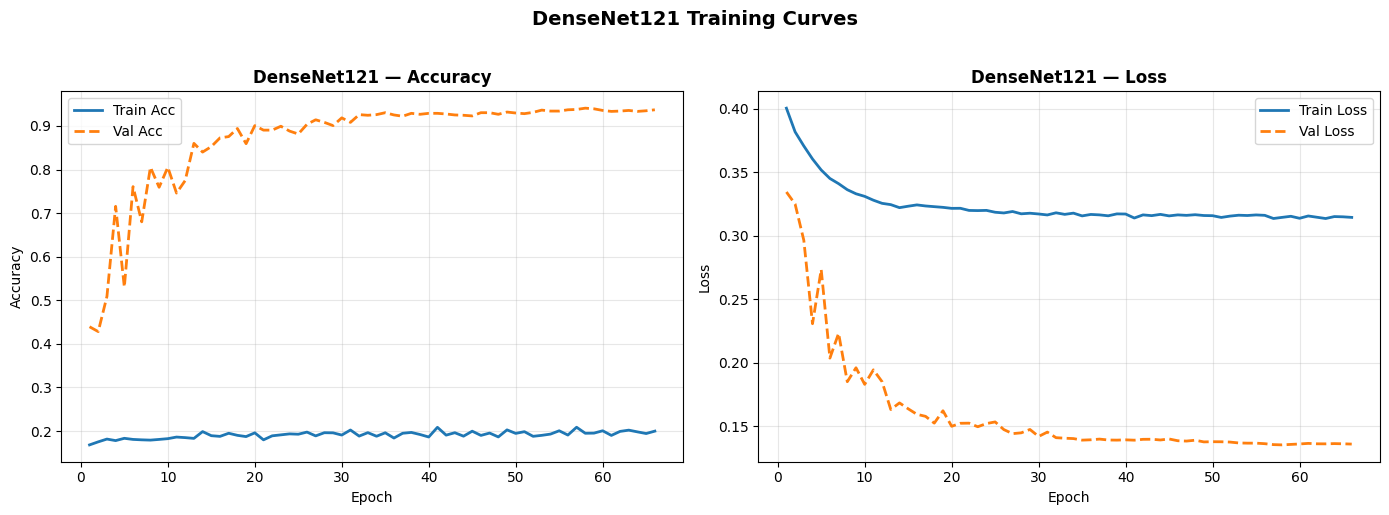

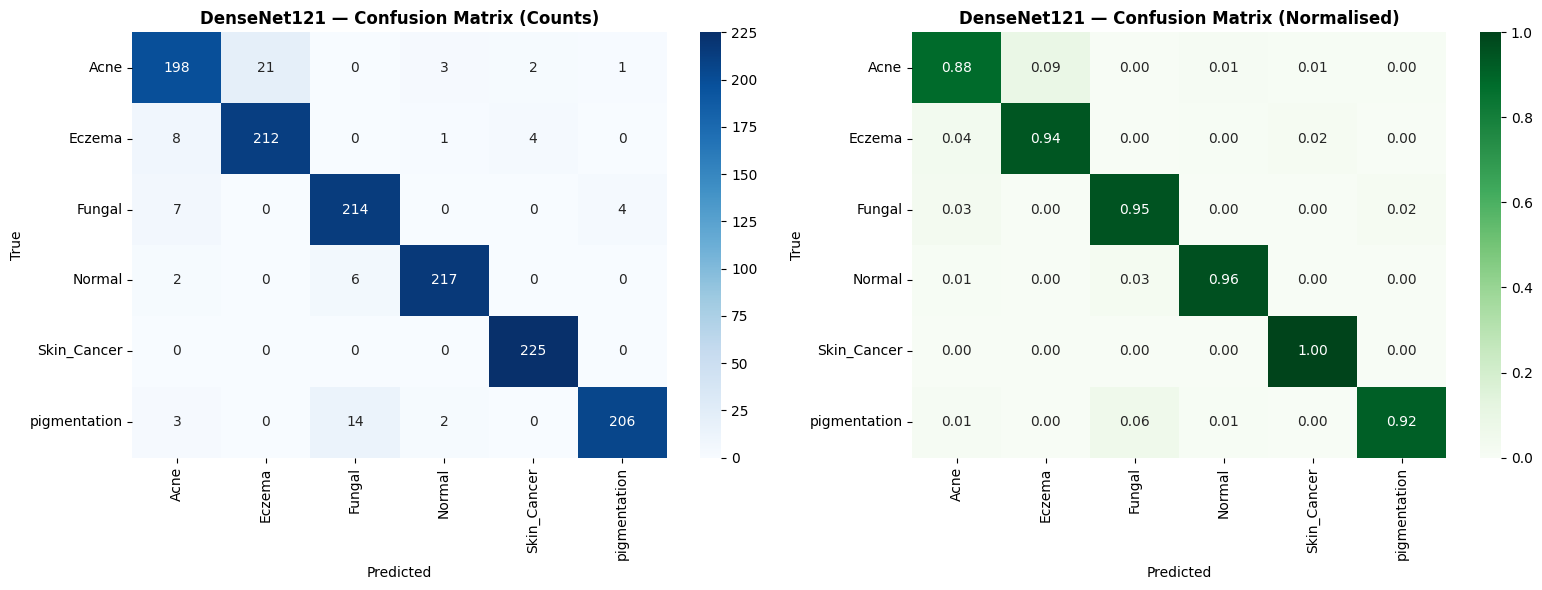

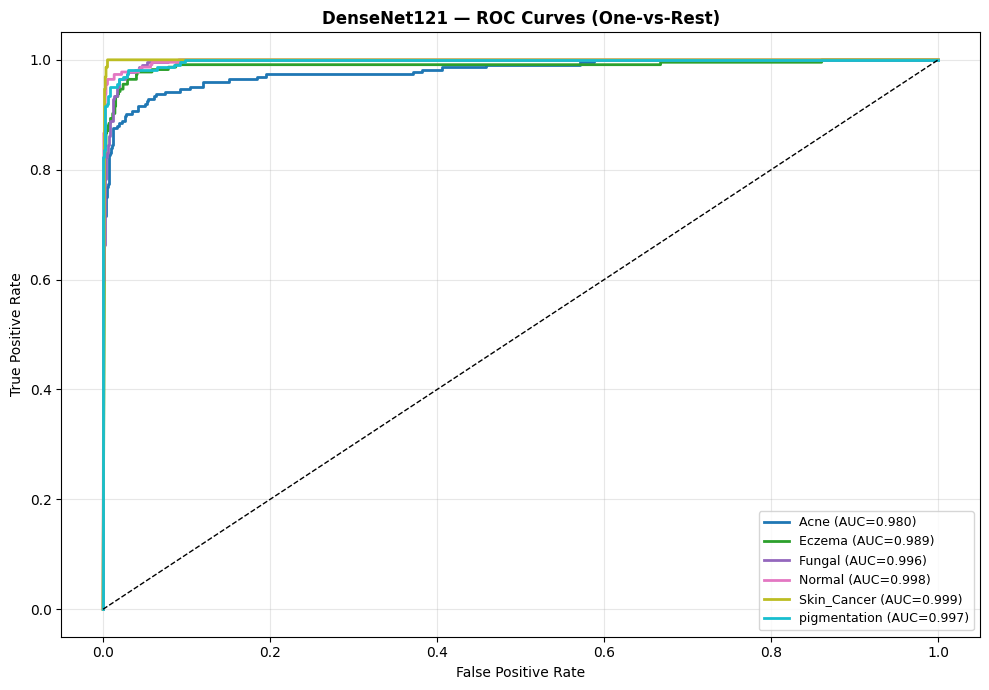

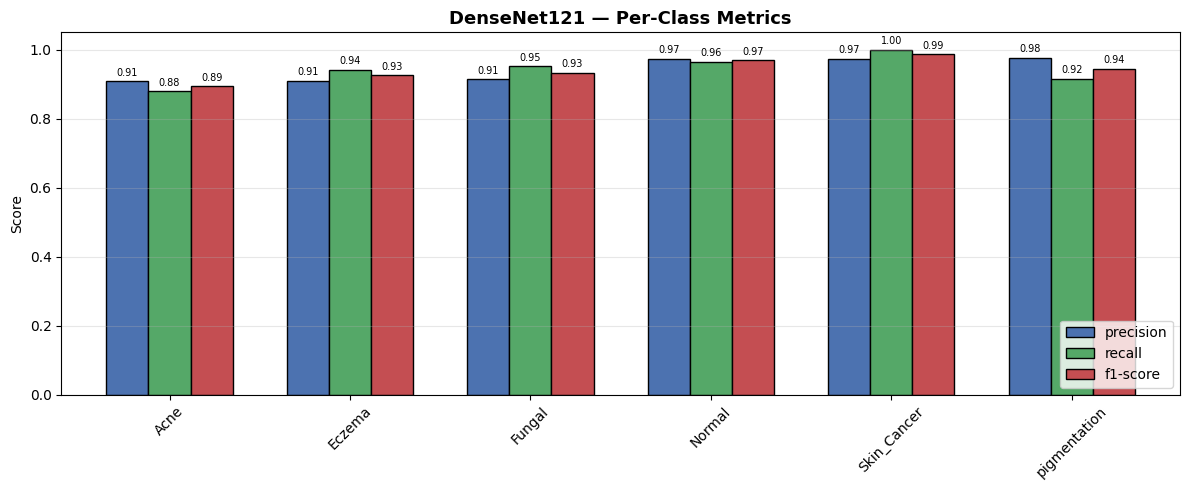

148857

In [16]:
densenet_base = DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
metrics_den = train_model_phased(
    model_name='DenseNet121',
    base_model=densenet_base,
    unfreeze_phase2=60,
    unfreeze_phase3=120,
)
del densenet_base; gc.collect()

## 🤖 Cell 17 — Train Model 4: MobileNetV3Large

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
  🔵 Training: MobileNetV3Large
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

📌 Phase 1 — Frozen backbone, warm up head
  → Backbone fully frozen
Epoch 1/15


2026-04-21 18:18:00.890156: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-21 18:18:01.028051: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


196/197 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.1641 - loss: 0.3989 - top2_accuracy: 0.3444

2026-04-21 18:19:11.198233: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-21 18:19:11.335908: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.1641 - loss: 0.3988 - top2_accuracy: 0.3443

2026-04-21 18:19:32.480543: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-21 18:19:32.620691: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-21 18:19:32.756992: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_accuracy improved from -inf to 0.21556, saving model to /kaggle/working/saved_models/MobileNetV3Large_p1_best.keras
197/197 ━━━━━━━━━━━━━━━━━━━━ 112s 465ms/step - accuracy: 0.1642 - loss: 0.3987 - top2_accuracy: 0.3443 - val_accuracy: 0.2156 - val_loss: 0.3577 - val_top2_accuracy: 0.4007 - learning_rate: 3.3333e-04
Epoch 2/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.1811 - loss: 0.3647 - top2_accuracy: 0.3467
Epoch 2: val_accuracy improved from 0.21556 to 0.49556, saving model to /kaggle/working/saved_models/MobileNetV3Large_p1_best.keras
197/197 ━━━━━━━━━━━━━━━━━━━━ 68s 343ms/step - accuracy: 0.1811 - loss: 0.3647 - top2_accuracy: 0.3467 - val_accuracy: 0.4956 - val_loss: 0.3028 - val_top2_accuracy: 0.6696 - learning_rate: 6.6667e-04
Epoch 3/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.1730 - loss: 0.3567 - top2_accuracy: 0.3487
Epoch 3: val_accuracy did not improve from 0.49556
197/197 ━━━━━━━━━━━━━━━━━━━━ 67s 338ms/step - accuracy: 0.1730

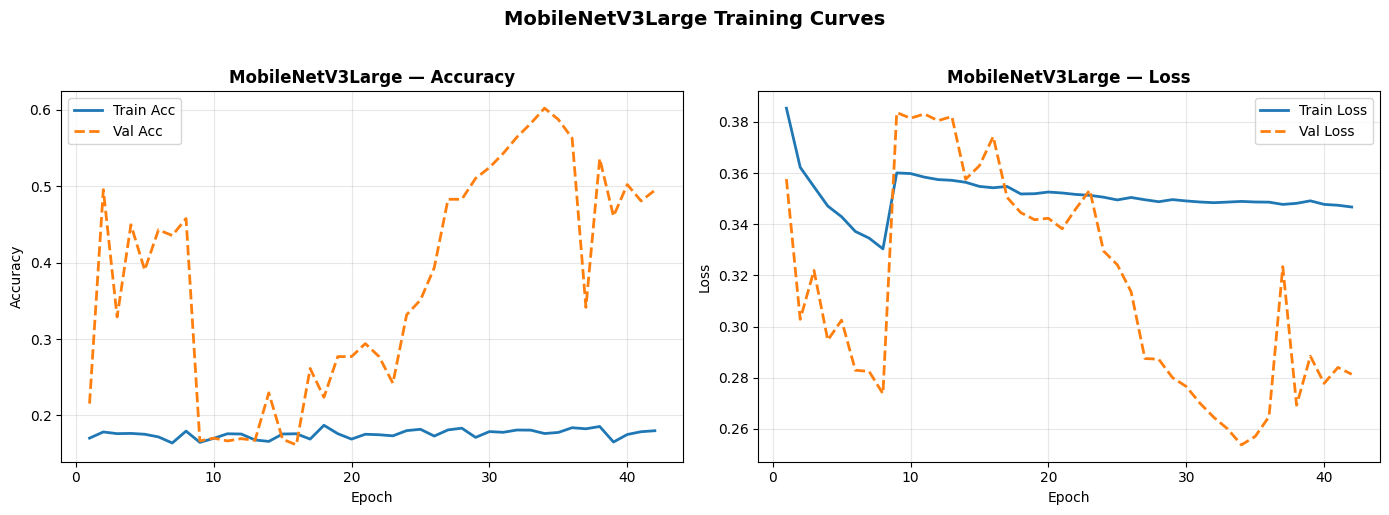

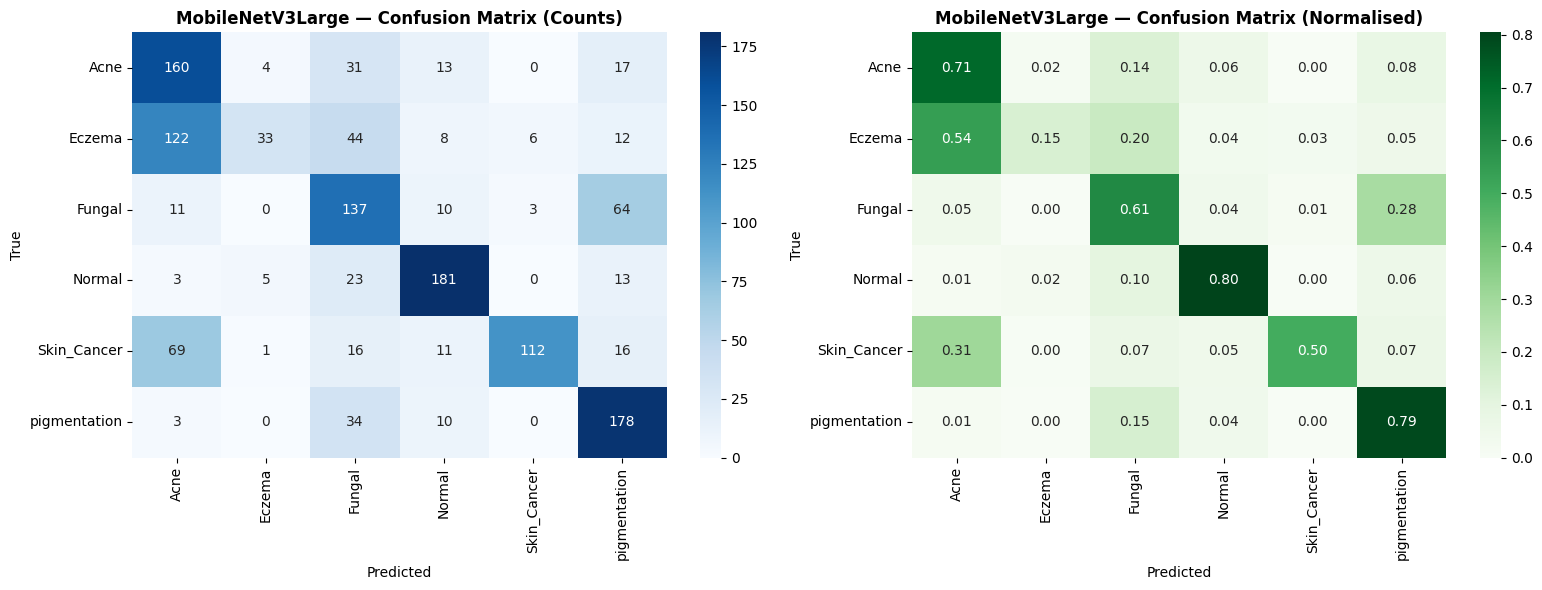

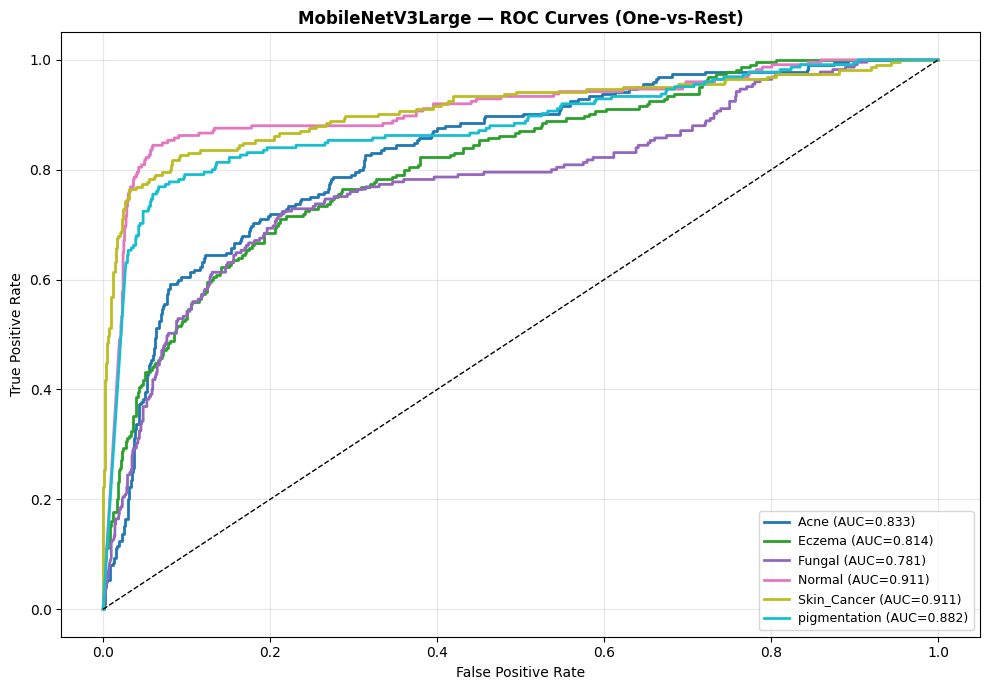

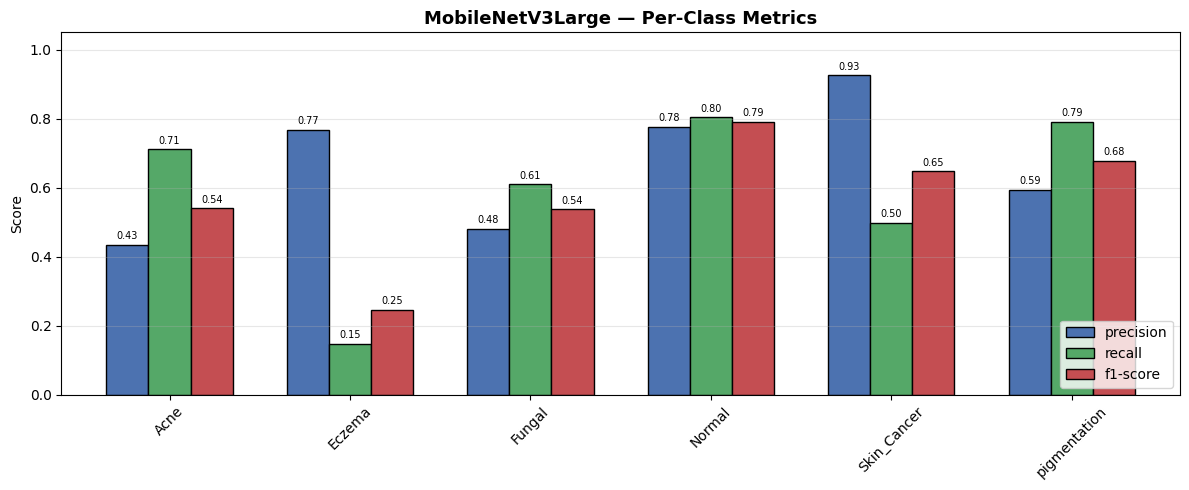

64528

In [17]:
mobilenet_base = MobileNetV3Large(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_preprocessing=True
)
metrics_mob = train_model_phased(
    model_name='MobileNetV3Large',
    base_model=mobilenet_base,
    unfreeze_phase2=25,
    unfreeze_phase3=60,
)
del mobilenet_base; gc.collect()

## 🤖 Cell 18 — Train Model 5: Vision Transformer (ViT-B16)

**Fix applied:** `SparseTopKCategoricalAccuracy` in all 3 phase compiles.

In [18]:
try:
    from vit_keras import vit
    vit_base_model = vit.vit_b16(
        image_size     = IMG_SIZE,
        activation     = 'softmax',
        pretrained     = True,
        include_top    = False,
        pretrained_top = False,
    )
    print(f'✅ ViT-B16 loaded | output shape: {vit_base_model.output_shape}')

    vit_input  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='vit_input')
    vit_out    = vit_base_model(vit_input, training=False)
    cls_token  = layers.Lambda(lambda t: t[:, 0, :], name='cls_token')(vit_out)
    x          = layers.BatchNormalization()(cls_token)
    x          = layers.Dense(512, activation='relu', kernel_regularizer=l2(L2_REG))(x)
    x          = layers.BatchNormalization()(x)
    x          = layers.Dropout(DROPOUT_RATE)(x)
    x          = layers.Dense(256, activation='relu', kernel_regularizer=l2(L2_REG))(x)
    x          = layers.Dropout(DROPOUT_RATE * 0.5)(x)
    vit_output = layers.Dense(NUM_CLASSES, activation='softmax', name='predictions')(x)
    vit_model  = Model(vit_input, vit_output, name='ViT_B16')

    histories_vit = []

    # Phase 1
    vit_base_model.trainable = False
    vit_model.compile(
        optimizer=Adam(BASE_LR),
        loss=FocalLoss(gamma=2.0),
        metrics=['accuracy',
                 keras.metrics.SparseTopKCategoricalAccuracy(k=2, name='top2_accuracy')]
    )
    cbs_v1, _ = make_callbacks('ViT_B16_p1', patience_es=6)
    h_v1 = vit_model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_PHASE1,
                         callbacks=cbs_v1, class_weight=CLASS_WEIGHT_DICT, verbose=1)
    histories_vit.append(h_v1.history)

    # Phase 2
    vit_base_model.trainable = True
    for layer in vit_base_model.layers[:-20]:
        layer.trainable = False
    vit_model.compile(
        optimizer=Adam(FINETUNE_LR),
        loss=FocalLoss(gamma=2.0),
        metrics=['accuracy',
                 keras.metrics.SparseTopKCategoricalAccuracy(k=2, name='top2_accuracy')]
    )
    cbs_v2, _ = make_callbacks('ViT_B16_p2', patience_es=7)
    h_v2 = vit_model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_PHASE2,
                         callbacks=cbs_v2, class_weight=CLASS_WEIGHT_DICT, verbose=1)
    histories_vit.append(h_v2.history)

    # Phase 3
    for layer in vit_base_model.layers:
        layer.trainable = True
    vit_model.compile(
        optimizer=AdamW(learning_rate=FULL_FT_LR, weight_decay=1e-5),
        loss=FocalLoss(gamma=2.0),
        metrics=['accuracy',
                 keras.metrics.SparseTopKCategoricalAccuracy(k=2, name='top2_accuracy')]
    )
    cbs_v3, _ = make_callbacks('ViT_B16_p3', patience_es=8)
    h_v3 = vit_model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_PHASE3,
                         callbacks=cbs_v3, class_weight=CLASS_WEIGHT_DICT, verbose=1)
    histories_vit.append(h_v3.history)

    vit_model.save(str(SAVE_DIR / 'ViT_B16_final.keras'))
    metrics_vit = evaluate_model(vit_model, test_ds, CLASS_NAMES, 'ViT_B16')
    print(f'ViT Accuracy: {metrics_vit["accuracy"]:.4f}')

    plot_training_history(histories_vit, 'ViT_B16', PLOT_DIR)
    plot_confusion_matrix(metrics_vit['y_true'], metrics_vit['y_pred'],
                          CLASS_NAMES, 'ViT_B16', PLOT_DIR)
    plot_roc_curves(metrics_vit['y_true'], metrics_vit['y_pred_prob'],
                    CLASS_NAMES, 'ViT_B16', PLOT_DIR)
    plot_per_class_metrics(metrics_vit['report'], CLASS_NAMES, 'ViT_B16', PLOT_DIR)

    ALL_METRICS.append(metrics_vit)
    ALL_HISTORIES['ViT_B16'] = histories_vit

    del vit_model, vit_base_model
    gc.collect(); K.clear_session()

except Exception as e:
    print(f'⚠️  ViT training skipped: {e}')
    print('   Check vit-keras is installed and internet is ON for pretrained weights.')

⚠️  ViT training skipped: No module named 'tensorflow_addons'
   Check vit-keras is installed and internet is ON for pretrained weights.


## 🏆 Cell 19 — Model Comparison Dashboard

In [19]:
comparison_rows = []
for m in ALL_METRICS:
    comparison_rows.append({
        'Model'        : m['model'],
        'Accuracy'     : m['accuracy'],
        'F1 (Macro)'   : m['f1_macro'],
        'F1 (Weighted)': m['f1_weighted'],
        'AUC-ROC'      : m['auc_roc'],
        'Cohen κ'      : m['kappa'],
        'MCC'          : m['mcc'],
    })

df_compare = pd.DataFrame(comparison_rows).sort_values(
    'Accuracy', ascending=False).reset_index(drop=True)

print('\n' + '='*75)
print('  📊  FULL MODEL COMPARISON TABLE')
print('='*75)
print(df_compare.to_string(index=False))
print('='*75)

best_model_name = df_compare.iloc[0]['Model']
best_accuracy   = df_compare.iloc[0]['Accuracy']
print(f'\n🏆 Best Model: {best_model_name}  |  Accuracy: {best_accuracy:.4f}')

df_compare.to_csv(SAVE_DIR / 'model_comparison.csv', index=False)
print('💾 Comparison table saved.')


  📊  FULL MODEL COMPARISON TABLE
           Model  Accuracy  F1 (Macro)  F1 (Weighted)  AUC-ROC  Cohen κ    MCC
     DenseNet121    0.9422      0.9421         0.9421   0.9932   0.9307 0.9308
        ResNet50    0.6104      0.5648         0.5648   0.9011   0.5324 0.5451
MobileNetV3Large    0.5933      0.5732         0.5732   0.8554   0.5120 0.5249
EfficientNetV2B0    0.2489      0.1779         0.1779   0.5315   0.0987 0.1097

🏆 Best Model: DenseNet121  |  Accuracy: 0.9422
💾 Comparison table saved.


## 📊 Cell 20 — Full Comparison Visualisation

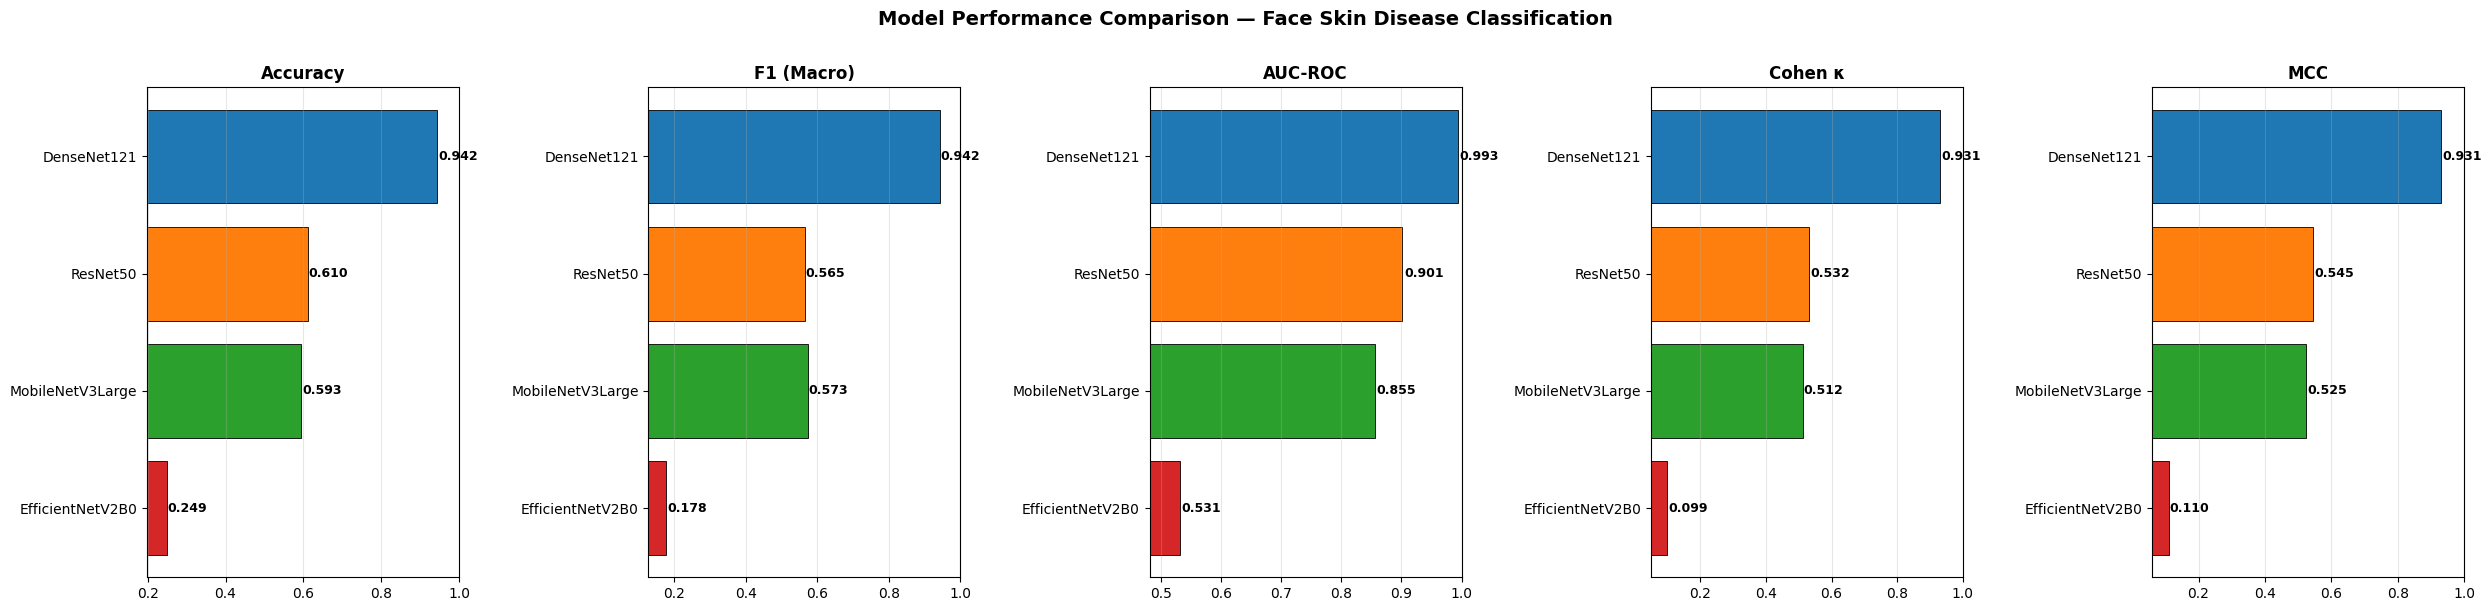

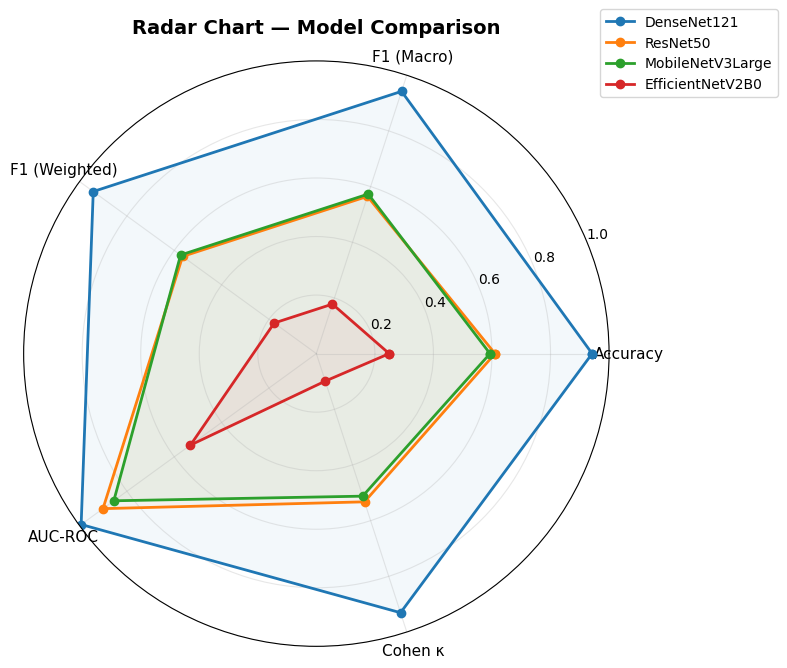

✅ Comparison plots saved.


In [20]:
metrics_to_plot = ['Accuracy', 'F1 (Macro)', 'AUC-ROC', 'Cohen κ', 'MCC']
palette         = sns.color_palette('tab10', n_colors=len(df_compare))

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(5 * len(metrics_to_plot), 6))
for ax, metric in zip(axes, metrics_to_plot):
    bars = ax.barh(df_compare['Model'], df_compare[metric],
                   color=palette, edgecolor='k', linewidth=0.6)
    ax.set_title(metric, fontweight='bold', fontsize=12)
    ax.set_xlim(max(0, df_compare[metric].min() - 0.05), 1.0)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    for bar, val in zip(bars, df_compare[metric]):
        ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Model Performance Comparison — Face Skin Disease Classification',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'model_comparison_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── Radar Chart ─────────────────────────────────────────────────────────────
radar_metrics = ['Accuracy', 'F1 (Macro)', 'F1 (Weighted)', 'AUC-ROC', 'Cohen κ']
N      = len(radar_metrics)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for i, row in df_compare.iterrows():
    values = [row[m] for m in radar_metrics] + [row[radar_metrics[0]]]
    ax.plot(angles, values, 'o-', linewidth=2, label=row['Model'])
    ax.fill(angles, values, alpha=0.05)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title('Radar Chart — Model Comparison', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'model_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Comparison plots saved.')

## 🎯 Cell 21 — Ensemble (Weighted Soft Voting)

📦 Found 4 saved models for ensemble.
  ✅ Loaded: DenseNet121_final.keras
  ✅ Loaded: MobileNetV3Large_final.keras
  ✅ Loaded: ResNet50_final.keras
  ✅ Loaded: EfficientNetV2B0_final.keras

Ensemble weights: {'DenseNet121_final': np.float64(0.393), 'MobileNetV3Large_final': np.float64(0.248), 'ResNet50_final': np.float64(0.255), 'EfficientNetV2B0_final': np.float64(0.104)}

🎯 ENSEMBLE Results:
  Accuracy   : 0.9052
  F1 (Macro) : 0.9049
  AUC-ROC    : 0.9865
  Cohen κ    : 0.8862

              precision    recall  f1-score   support

        Acne       0.89      0.86      0.87       225
      Eczema       0.91      0.93      0.92       225
      Fungal       0.94      0.79      0.86       225
      Normal       0.94      0.96      0.95       225
 Skin_Cancer       0.97      0.96      0.96       225
pigmentation       0.81      0.94      0.87       225

    accuracy                           0.91      1350
   macro avg       0.91      0.91      0.90      1350
weighted avg       0.91    

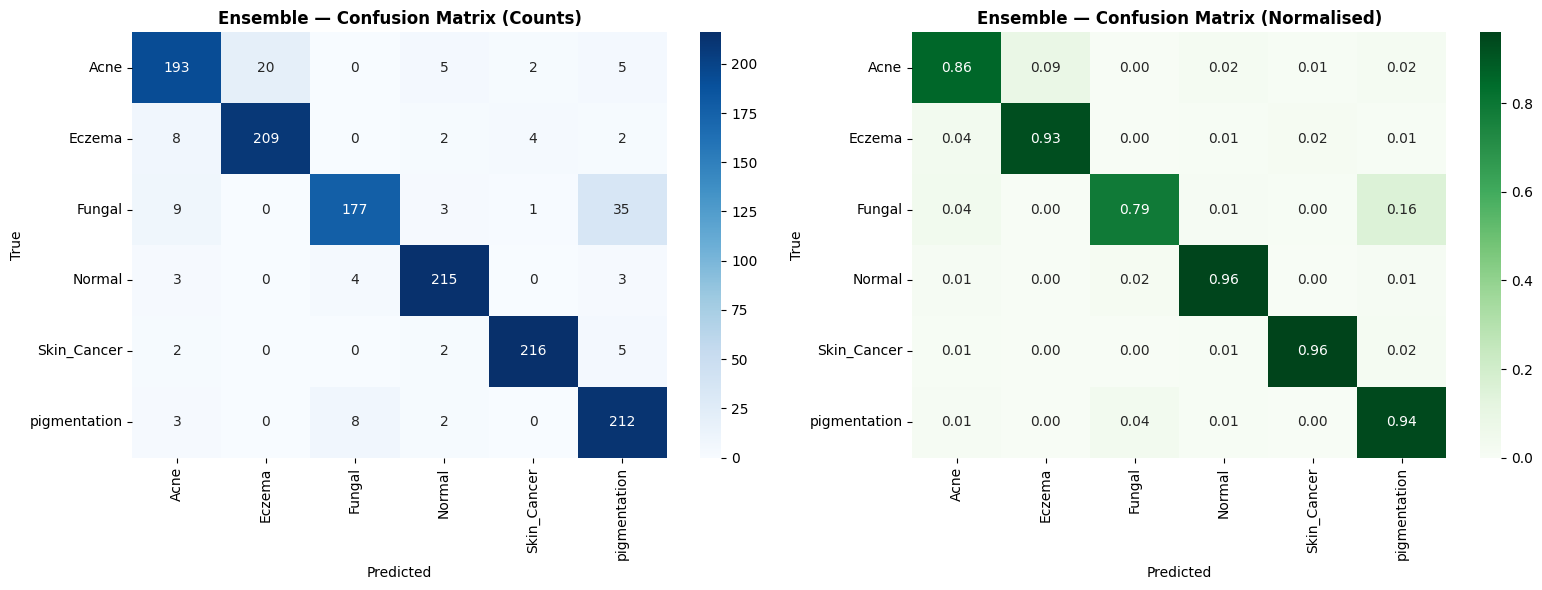

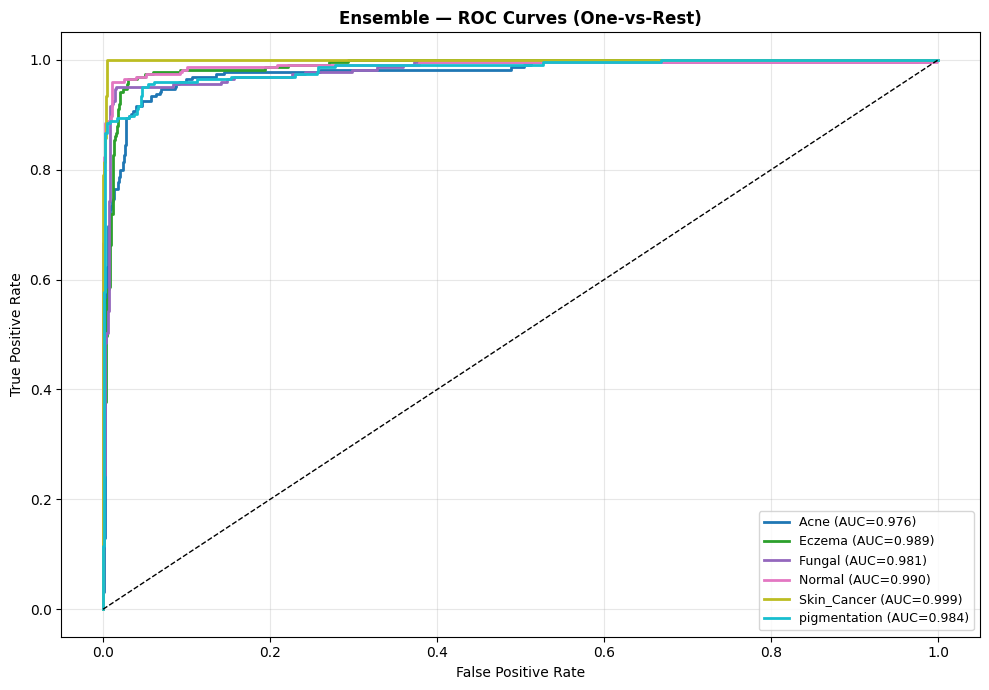


📊 Final Comparison (including Ensemble):
              Model  Accuracy  F1 (Macro)  AUC-ROC  Cohen κ
        DenseNet121    0.9422      0.9421   0.9932   0.9307
Ensemble (Weighted)    0.9052      0.9049   0.9865   0.8862
           ResNet50    0.6104      0.5648   0.9011   0.5324
   MobileNetV3Large    0.5933      0.5732   0.8554   0.5120
   EfficientNetV2B0    0.2489      0.1779   0.5315   0.0987


In [21]:
model_files = list(SAVE_DIR.glob('*_final.keras'))
print(f'📦 Found {len(model_files)} saved models for ensemble.')

if len(model_files) >= 2:
    ensemble_models = []
    for mf in model_files:
        try:
            m = keras.models.load_model(
                str(mf), custom_objects={'FocalLoss': FocalLoss})
            ensemble_models.append(m)
            print(f'  ✅ Loaded: {mf.name}')
        except Exception as e:
            print(f'  ⚠️  Could not load {mf.name}: {e}')

    y_true_ens = []
    probs_list = [[] for _ in ensemble_models]
    for images, labels in test_ds:
        y_true_ens.extend(labels.numpy())
        for idx, em in enumerate(ensemble_models):
            probs_list[idx].extend(em.predict(images, verbose=0))

    y_true_ens   = np.array(y_true_ens)
    probs_arrays = [np.array(p) for p in probs_list]

    # Performance-weighted ensemble
    model_accuracies = [(np.argmax(p, axis=1) == y_true_ens).mean() for p in probs_arrays]
    weights          = np.array(model_accuracies)
    weights          = weights / weights.sum()
    print(f'\nEnsemble weights: {dict(zip([mf.stem for mf in model_files], weights.round(3)))}')

    ensemble_probs = sum(w * p for w, p in zip(weights, probs_arrays))
    y_pred_ens     = np.argmax(ensemble_probs, axis=1)

    ens_acc   = (y_pred_ens == y_true_ens).mean()
    ens_f1    = f1_score(y_true_ens, y_pred_ens, average='macro', zero_division=0)
    ens_kappa = cohen_kappa_score(y_true_ens, y_pred_ens)
    y_bin_ens = label_binarize(y_true_ens, classes=np.arange(NUM_CLASSES))
    try:
        ens_auc = roc_auc_score(y_bin_ens, ensemble_probs,
                                 average='macro', multi_class='ovr')
    except Exception:
        ens_auc = float('nan')

    print(f'\n🎯 ENSEMBLE Results:')
    print(f'  Accuracy   : {ens_acc:.4f}')
    print(f'  F1 (Macro) : {ens_f1:.4f}')
    print(f'  AUC-ROC    : {ens_auc:.4f}')
    print(f'  Cohen κ    : {ens_kappa:.4f}')
    print('\n' + classification_report(
        y_true_ens, y_pred_ens, target_names=CLASS_NAMES, zero_division=0))

    plot_confusion_matrix(y_true_ens, y_pred_ens, CLASS_NAMES, 'Ensemble', PLOT_DIR)
    plot_roc_curves(y_true_ens, ensemble_probs, CLASS_NAMES, 'Ensemble', PLOT_DIR)

    ens_row = pd.DataFrame([{
        'Model'        : 'Ensemble (Weighted)',
        'Accuracy'     : round(float(ens_acc), 4),
        'F1 (Macro)'   : round(float(ens_f1), 4),
        'F1 (Weighted)': float('nan'),
        'AUC-ROC'      : round(float(ens_auc), 4),
        'Cohen κ'      : round(float(ens_kappa), 4),
        'MCC'          : float('nan')
    }])
    df_compare_final = pd.concat([df_compare, ens_row], ignore_index=True).sort_values(
        'Accuracy', ascending=False)
    df_compare_final.to_csv(SAVE_DIR / 'model_comparison_with_ensemble.csv', index=False)
    print('\n📊 Final Comparison (including Ensemble):')
    print(df_compare_final[['Model', 'Accuracy', 'F1 (Macro)', 'AUC-ROC', 'Cohen κ']].to_string(index=False))

else:
    print('⚠️  Need at least 2 trained models for ensemble. Skipping.')

## 💡 Cell 22 — Best Model Recommendation & Final Summary

In [22]:
print('='*75)
print('  🏆  FINAL RECOMMENDATION')
print('='*75)

if len(ALL_METRICS) > 0:
    best = max(ALL_METRICS, key=lambda x: x['accuracy'])
    print(f"\n🥇 Best Single Model : {best['model']}")
    print(f"   Accuracy          : {best['accuracy']:.4f}")
    print(f"   F1 (Macro)        : {best['f1_macro']:.4f}")
    print(f"   AUC-ROC           : {best['auc_roc']:.4f}")
    print(f"   Cohen κ           : {best['kappa']:.4f}")
    print(f"   MCC               : {best['mcc']:.4f}")

    print(f"""
📌 Deployment Guidance:
  • Best Accuracy  → Ensemble (Weighted Soft Voting)
  • Best Speed     → MobileNetV3Large
  • Best Balance   → {best['model']}

📂 Saved in /kaggle/working/saved_models/:
  • <Model>_final.keras        — full trained model
  • <Model>_best.keras         — best checkpoint per phase
  • <Model>_training_log.csv   — epoch logs
  • model_comparison.csv
  • model_comparison_with_ensemble.csv
  • label_map.json
""")

# Save label map
label_map = {i: cls for i, cls in enumerate(CLASS_NAMES)}
with open(SAVE_DIR / 'label_map.json', 'w') as f:
    json.dump(label_map, f, indent=2)
print(f'✅ Label map saved: {label_map}')
print('\n✅ Pipeline complete. Ready for deployment!')

  🏆  FINAL RECOMMENDATION

🥇 Best Single Model : DenseNet121
   Accuracy          : 0.9422
   F1 (Macro)        : 0.9421
   AUC-ROC           : 0.9932
   Cohen κ           : 0.9307
   MCC               : 0.9308

📌 Deployment Guidance:
  • Best Accuracy  → Ensemble (Weighted Soft Voting)
  • Best Speed     → MobileNetV3Large
  • Best Balance   → DenseNet121

📂 Saved in /kaggle/working/saved_models/:
  • <Model>_final.keras        — full trained model
  • <Model>_best.keras         — best checkpoint per phase
  • <Model>_training_log.csv   — epoch logs
  • model_comparison.csv
  • model_comparison_with_ensemble.csv
  • label_map.json

✅ Label map saved: {0: 'Acne', 1: 'Eczema', 2: 'Fungal', 3: 'Normal', 4: 'Skin_Cancer', 5: 'pigmentation'}

✅ Pipeline complete. Ready for deployment!


## 🔍 Cell 23 — Inference Demo (Single Image)

In [23]:
from PIL import Image as PILImage

def predict_single_image(image_path: str, model_path: str, label_map: dict, img_size: int = 224):
    model = keras.models.load_model(
        model_path, custom_objects={'FocalLoss': FocalLoss})

    # ─── PIL-based loading: handles TIFF/WebP/any misnamed format ────────────
    with PILImage.open(image_path) as pil_img:
        pil_img = pil_img.convert('RGB').resize((img_size, img_size), PILImage.BILINEAR)
        img_np  = np.array(pil_img, dtype=np.float32) / 255.0

    img = tf.constant(img_np)
    img = tf.clip_by_value(img, 0.0, 1.0)
    img = tf.expand_dims(img, 0)   # add batch dimension → (1, H, W, 3)

    probs      = model.predict(img, verbose=0)[0]
    pred_idx   = int(np.argmax(probs))
    pred_class = label_map[pred_idx]
    confidence = float(probs[pred_idx])

    plt.figure(figsize=(5, 5))
    plt.imshow(np.clip(img[0].numpy(), 0, 1))
    plt.title(f'Predicted: {pred_class}\nConfidence: {confidence:.2%}',
              fontsize=13, fontweight='bold',
              color='green' if confidence > 0.7 else 'orange')
    plt.axis('off'); plt.tight_layout(); plt.show()

    plt.figure(figsize=(8, 4))
    colors = ['green' if i == pred_idx else 'steelblue' for i in range(len(label_map))]
    plt.bar(list(label_map.values()), probs, color=colors, edgecolor='k')
    plt.ylabel('Probability'); plt.title('Class Probability Distribution')
    plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

    return pred_class, confidence


# ─── Example (uncomment and update path to test) ─────────────────────────────
# pred_class, conf = predict_single_image(
#     image_path = '/kaggle/input/Face_data/Acne/some_image.jpg',
#     model_path = str(SAVE_DIR / 'EfficientNetV2B0_final.keras'),
#     label_map  = label_map,
# )
# print(f'Prediction: {pred_class}  |  Confidence: {conf:.2%}')

print('✅ Inference helper ready.')

✅ Inference helper ready.
